In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vishalkumard/malicious-xapp/DES_Final.csv


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# pip install torch-scatter

In [5]:
import pandas as pd
df=pd.read_csv('/kaggle/input/datasets/vishalkumard/malicious-xapp/DES_Final.csv')
print(df.head())
df.columns

   timestamp  xapp_id             action_type  target_ue  target_cell  \
0          0        0  rmr_route_manipulation        119            1   
1          0        0   prb_allocation_adjust        819            9   
2          0        1       scheduling_change        133            5   
3          0        2       scheduling_change        291            2   
4          0        2            mcs_override        347            9   

   param_value  window_id    rsrp   sinr  cell_load  ...  prb_usage_dl  \
0          1.0          0 -109.09  19.16     0.9900  ...       58.7036   
1         12.0          0  -69.42   5.03     0.9900  ...       58.7036   
2          8.0          0  -97.89   0.68     0.9900  ...       46.4570   
3          8.0          0  -96.66  -3.84     0.7962  ...       43.8499   
4         14.0          0  -79.51   3.08     0.7049  ...       43.8499   

   prb_usage_ul  total_prb_available  ue_count_raw  rmr_msg_rate  \
0       25.4840                  100          10

Index(['timestamp', 'xapp_id', 'action_type', 'target_ue', 'target_cell',
       'param_value', 'window_id', 'rsrp', 'sinr', 'cell_load', 'ue_count',
       'throughput', 'qos_score', 'sinr_delta', 'throughput_delta',
       'qos_delta', 'msg_type', 'routing_key', 'xapp_home_cell', 'load_mode',
       'prb_usage_dl', 'prb_usage_ul', 'total_prb_available', 'ue_count_raw',
       'rmr_msg_rate', 'rmr_msg_size_avg', 'cpu_usage', 'memory_usage',
       'execution_latency', 'is_malicious'],
      dtype='object')

In [6]:
# !pip install torch 
# !pip install scikit-learn
# !pip install torch_geometric

In [8]:
# !pip uninstall -y torch_geometric

In [8]:

!pip install torch_geometric==2.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s eta 0:00:0000:01


In [9]:
#global graph

In [9]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data

class GlobalGraphBuilder:
    def __init__(self, config):
        self.num_xapps = config["topology"]["num_xapps"]  # 15
        self.num_cells = config["topology"]["num_cells"]  # 3
        self.num_ues   = config["topology"]["num_ues"]    # 150
        
        # Define ID Ranges
        self.xapp_range = range(0, self.num_xapps)
        self.cell_range = range(self.num_xapps, self.num_xapps + self.num_cells)
        self.ue_range   = range(self.num_xapps + self.num_cells, 
                                self.num_xapps + self.num_cells + self.num_ues)
        
        self.total_nodes = self.num_xapps + self.num_cells + self.num_ues
        
        # Scalers
        self.scaler_xapp = StandardScaler()
        self.scaler_ue   = StandardScaler()
        self.scaler_cell = StandardScaler()
        self.is_fitted = False

    def fit(self, df: pd.DataFrame):
        """Fits scalers on the entire dataset first."""
        xapp_feats = df[['cpu_usage', 'memory_usage', 'rmr_msg_rate', 'prb_usage_dl']].values
        ue_feats   = df[['rsrp', 'sinr', 'throughput']].values
        cell_feats = df[['cell_load', 'ue_count']].values
        
        self.scaler_xapp.fit(xapp_feats)
        self.scaler_ue.fit(ue_feats)
        self.scaler_cell.fit(cell_feats)
        self.is_fitted = True
        print("Scalers fitted.")

    def build_window_graphs(self, df_window: pd.DataFrame):
        """
        Creates one global graph for every timestamp in the window.
        Returns: List of 120 Data objects.
        """
        if not self.is_fitted: raise ValueError("Run .fit(df) first!")
        
        global_graphs = []
        timestamps = sorted(df_window['timestamp'].unique())
        
        for t in timestamps:
            df_t = df_window[df_window['timestamp'] == t]
            
            # --- 1. Node Features (Total Nodes x 12 Features) ---
            # Format: [is_xapp, is_cell, is_ue, xapp_f1..f4, cell_f1..f2, ue_f1..f3]
            x = np.zeros((self.total_nodes, 12), dtype=np.float32)
            
            # Fill xApps
            xapp_data = df_t.drop_duplicates('xapp_id').set_index('xapp_id')
            for xid in range(self.num_xapps):
                idx = xid  # 0 to 14
                x[idx, 0] = 1 # One-Hot Type
                if xid in xapp_data.index:
                    feats = xapp_data.loc[xid, ['cpu_usage', 'memory_usage', 'rmr_msg_rate', 'prb_usage_dl']].values.reshape(1, -1)
                    x[idx, 3:7] = self.scaler_xapp.transform(feats)

            # Fill Cells
            cell_data = df_t.drop_duplicates('target_cell').set_index('target_cell')
            for cid in range(self.num_cells):
                idx = self.num_xapps + cid
                x[idx, 1] = 1 # One-Hot Type
                if cid in cell_data.index:
                    feats = cell_data.loc[cid, ['cell_load', 'ue_count']].values.reshape(1, -1)
                    x[idx, 7:9] = self.scaler_cell.transform(feats)

            # Fill UEs
            ue_data = df_t.drop_duplicates('target_ue').set_index('target_ue')
            for uid in range(self.num_ues):
                idx = self.num_xapps + self.num_cells + uid
                x[idx, 2] = 1 # One-Hot Type
                if uid in ue_data.index:
                    feats = ue_data.loc[uid, ['rsrp', 'sinr', 'throughput']].values.reshape(1, -1)
                    x[idx, 9:12] = self.scaler_ue.transform(feats)

            # --- 2. Edge Index ---
            src, dst = [], []
            
            # xApp <-> UE (Interaction)
            for _, row in df_t.iterrows():
                u_idx = int(row['xapp_id'])
                v_idx = self.num_xapps + self.num_cells + int(row['target_ue'])
                
                src.extend([u_idx, v_idx])
                dst.extend([v_idx, u_idx])

            # UE <-> Cell (Association)
            # We use the unique UEs to avoid duplicate edges
            for _, row in ue_data.iterrows():
                u_idx = self.num_xapps + self.num_cells + int(row.name) # UE ID is index
                c_idx = self.num_xapps + int(row['target_cell'])
                
                src.extend([u_idx, c_idx])
                dst.extend([c_idx, u_idx])

            # --- 3. Labels (Node Level) ---
            # We store labels for xApps in a mask or specific tensor
            # 0=Benign, 1=Malicious, -1=Not Applicable (Cells/UEs)
            y = torch.full((self.total_nodes,), -1, dtype=torch.long)
            
            # Since 'is_malicious' is in xapp_data
            for xid in range(self.num_xapps):
                if xid in xapp_data.index:
                    y[xid] = int(xapp_data.loc[xid, 'is_malicious'])
                else:
                    y[xid] = 0 # Default benign if idle
            
            # Create Data Object
            data = Data(
                x=torch.tensor(x, dtype=torch.float),
                edge_index=torch.tensor([src, dst], dtype=torch.long),
                y=y,
                timestamp=t
            )
            global_graphs.append(data)
            
        return global_graphs

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print(torch.__version__)

2.9.0+cu126


In [12]:
#ego graph

In [11]:
from torch_geometric.utils import k_hop_subgraph

def generate_ego_graphs(global_graphs, num_xapps=15, num_hops=2):
    """
    Input: List of 120 Global Graphs
    Output: List of 120 * 15 = 1800 Ego Graphs
    """
    ego_dataset = []
    
    for global_data in global_graphs:
        # Loop through every xApp to create its ego graph
        for xid in range(num_xapps):
            
            # The xApp node index is just xid (since they are 0-14)
            subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
                node_idx=xid, 
                num_hops=num_hops, 
                edge_index=global_data.edge_index, 
                relabel_nodes=True
            )
            
            # Construct the new Ego Data object
            ego_data = Data(
                x=global_data.x[subset],        # Features of only the subgraph nodes
                edge_index=sub_edge_index,      # Edges within the subgraph
                
                # The label of the CENTER xApp (the 'ego')
                y=global_data.y[xid].unsqueeze(0), 
                
                # Which node index in the NEW 'x' is the center xApp?
                root_node=mapping[0],           
                
                # Metadata
                global_timestamp=global_data.timestamp,
                global_xapp_id=xid
            )
            
            ego_dataset.append(ego_data)
            
    return ego_dataset

# ==============================================================================
# EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # 1. Setup
    CONFIG = {"topology": {"num_xapps": 50, "num_ues": 1000, "num_cells": 10}}
    df = pd.read_csv("/kaggle/input/datasets/vishalkumard/malicious-xapp/DES_Final.csv")
    
    # 2. Build Global Graphs
    builder = GlobalGraphBuilder(CONFIG)
    builder.fit(df) # Fit scalers on everything
    
    # Slice first 120 timestamps
    window_df = df[df['timestamp'] < 200]    # 10000 / 50
    
    print(f"Creating Global Graphs for {len(window_df['timestamp'].unique())} timestamps...")
    global_graphs = builder.build_window_graphs(window_df)
    print(f"Global Graphs Created: {len(global_graphs)}") # Should be 200
    
    # 3. Extract Ego Graphs
    print("Extracting Ego Graphs...")
    ego_dataset = generate_ego_graphs(global_graphs, num_xapps=50)
    
    print(f"Total Ego Graphs: {len(ego_dataset)}") # Should be 10,000
    
    # Verification
    g = ego_dataset[2]
    print("\n--- Sample Ego Graph 2 ---")
    print(f"Nodes: {g.x.shape[0]}")
    print(f"Edges: {g.edge_index.shape[1]}")
    print(f"Label: {g.y.item()}")
    print(f"Root Node Index: {g.root_node}")

Scalers fitted.
Creating Global Graphs for 200 timestamps...
Global Graphs Created: 200
Extracting Ego Graphs...
Total Ego Graphs: 10000

--- Sample Ego Graph 2 ---
Nodes: 7
Edges: 12
Label: 0
Root Node Index: 0


In [ ]:
#global graph visuaization

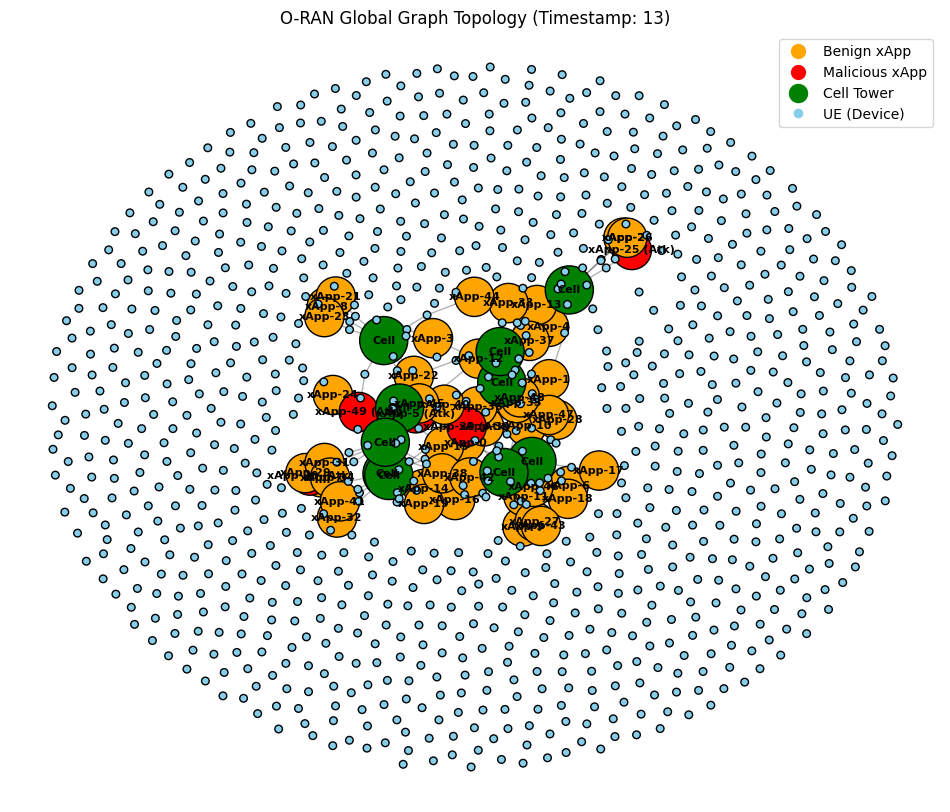

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def draw_global_graph(data):
    """
    Visualizes a single global graph snapshot (one timestamp).
    Nodes are colored by type: xApp (Benign/Malicious), Cell, UE.
    """
    # 1. Convert PyG Data to NetworkX (undirected for visualization)
    G = to_networkx(data, to_undirected=True)
    
    # 2. Assign Colors based on Node Type (One-Hot Features)
    # x[:, 0] = is_xapp
    # x[:, 1] = is_cell
    # x[:, 2] = is_ue
    # y[:]    = label (1=Malicious, 0=Benign for xApps)
    
    node_colors = []
    node_sizes = []
    labels = {}
    
    x_feats = data.x.numpy()
    y_labels = data.y.numpy()
    
    for i in range(len(G.nodes)):
        # Identify Node Type
        if x_feats[i, 0] == 1:  # xApp
            if y_labels[i] == 1:
                node_colors.append('red')      # Malicious xApp
                labels[i] = f"xApp-{i} (Atk)"
            else:
                node_colors.append('orange')   # Benign xApp
                labels[i] = f"xApp-{i}"
            node_sizes.append(800)
            
        elif x_feats[i, 1] == 1: # Cell
            node_colors.append('green')
            labels[i] = f"Cell"
            node_sizes.append(1200)
            
        elif x_feats[i, 2] == 1: # UE
            node_colors.append('skyblue')
            # labels[i] = "UE" # Optional: Skip UE labels to avoid clutter
            node_sizes.append(30)
            
        else:
            node_colors.append('grey') # Fallback
            node_sizes.append(100)

    # 3. Layout (Spring layout tends to separate clusters well)
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42, k=0.15, iterations=50)
    
    # 4. Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black')
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight="bold")
    
    # 5. Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Benign xApp', markersize=12),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Malicious xApp', markersize=12),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', label='Cell Tower', markersize=15),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', label='UE (Device)', markersize=8)
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title(f"O-RAN Global Graph Topology (Timestamp: {data.timestamp})")
    plt.axis('off')
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # Assuming 'global_graphs' list exists from your previous step
    if 'global_graphs' in locals() and len(global_graphs) > 0:
        # Visualize the first window (Timestamp 0)
        draw_global_graph(global_graphs[13])
    else:
        print("Please run the graph building code first to generate 'global_graphs'.")

In [ ]:
#ego graphh visualization

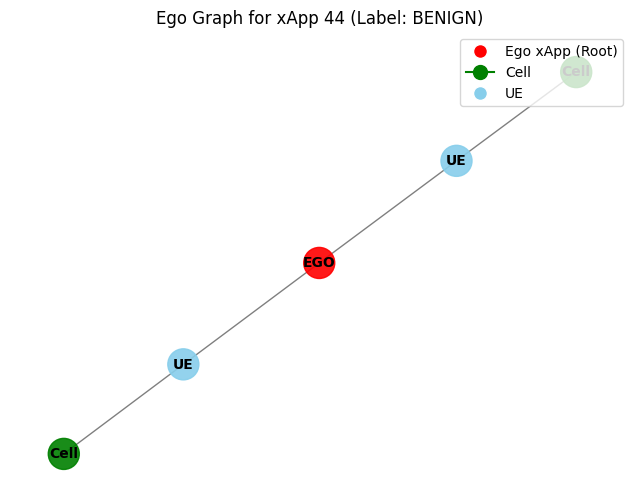

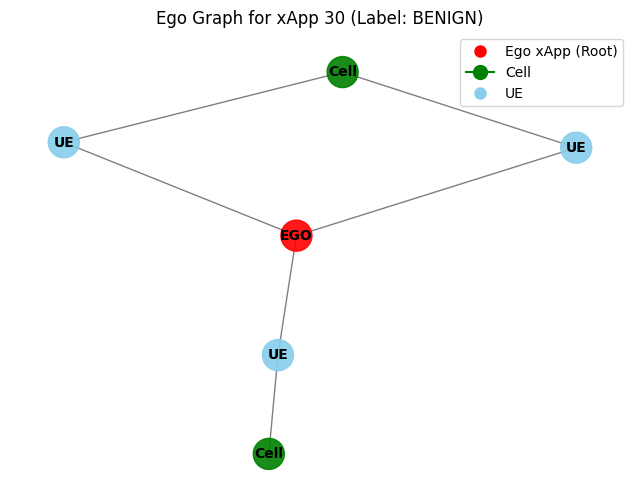

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def draw_ego_graph(ego_data):
    # 1. Convert PyG Data to NetworkX
    G = to_networkx(ego_data, to_undirected=True)

    # 2. Determine Node Colors & Labels
    node_colors = []
    labels = {}
    
    # Feature indices for One-Hot Encoding: 
    # Index 0 = xApp, Index 1 = Cell, Index 2 = UE
    x_feats = ego_data.x.numpy()
    
    for i in range(len(G.nodes)):
        if i == ego_data.root_node:
            # The Ego Node (Center xApp)
            node_colors.append('red') 
            labels[i] = "EGO"
        elif x_feats[i, 0] == 1:
            # Other xApps (if any nearby)
            node_colors.append('orange')
            labels[i] = "xApp"
        elif x_feats[i, 1] == 1:
            # Cells
            node_colors.append('green')
            labels[i] = "Cell"
        elif x_feats[i, 2] == 1:
            # UEs
            node_colors.append('skyblue')
            labels[i] = "UE"
        else:
            node_colors.append('grey')
            labels[i] = "?"

    # 3. Draw
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)  # Consistent layout
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.9)
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
    
    # Draw Labels
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight="bold")
    
    # Add Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Ego xApp (Root)', markersize=10),
        plt.Line2D([0], [0], marker='o', color='green', markerfacecolor='green', label='Cell', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', label='UE', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    status = "MALICIOUS" if ego_data.y.item() == 1 else "BENIGN"
    plt.title(f"Ego Graph for xApp {ego_data.global_xapp_id} (Label: {status})")
    plt.axis('off')
    plt.show()

# --- Run Visualization on the first generated graph ---
if __name__ == "__main__":
    # Assuming 'ego_dataset' exists from your previous code
    if 'ego_dataset' in locals() and len(ego_dataset) > 0:
        draw_ego_graph(ego_dataset[5544])
        draw_ego_graph(ego_dataset[2030])
        
    else:
        print("No ego_dataset found. Please run the generation code first.")

In [ ]:
#model

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool, GraphNorm
from torch_geometric.utils import dropout_edge
from torch_geometric.loader import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, 
    precision_recall_curve, confusion_matrix, roc_curve, auc
)

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
TRAIN_SPLITS_TO_TEST = [0.6] 
BATCH_SIZE = 64
LEARNING_RATE = 0.01
EPOCHS = 50               
SEED = 42
CONTRASTIVE_WEIGHT = 0.1  
CONTRASTIVE_TEMP = 0.5    

torch.manual_seed(SEED)
np.random.seed(SEED)

# Global list to store experiment results
all_experiment_results = []

# ==============================================================================
# 2. UTILITY FUNCTIONS
# ==============================================================================
def get_optimal_threshold(labels, logits):
    """Calculates the optimal prediction threshold by maximizing the F1 score on the PR curve."""
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    precisions, recalls, thresholds = precision_recall_curve(labels, probs)
    
    f1_scores = np.divide(
        2 * precisions * recalls, 
        precisions + recalls, 
        out=np.zeros_like(precisions), 
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_threshold

def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized Temperature-scaled Cross Entropy Loss for Graph Contrastive Learning."""
    device = z1.device
    batch_size = z1.size(0)
    
    z1 = F.normalize(z1, p=2, dim=1)
    z2 = F.normalize(z2, p=2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    
    sim_matrix = torch.mm(z, z.t()) / temperature
    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    sim_matrix = sim_matrix.masked_fill(mask, -9e15)
    
    targets = torch.cat([torch.arange(batch_size, 2*batch_size), 
                         torch.arange(0, batch_size)]).to(device)
    return F.cross_entropy(sim_matrix, targets)

# ==============================================================================
# 3. MODEL DEFINITION
# ==============================================================================
class AttentionGuidedEgoGAT(nn.Module):
    def __init__(self, num_node_features, hidden_channels, heads=4, num_classes=1, dropout=0.5, edge_dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.edge_dropout = edge_dropout
        self.hidden_channels = hidden_channels
        self.heads = heads
        self.ego_gate = nn.Linear(hidden_channels, hidden_channels * 2)

        self.res_proj1 = nn.Linear(num_node_features, hidden_channels * heads)
        self.res_proj2 = nn.Linear(hidden_channels * heads, hidden_channels)

        self.conv1 = GATv2Conv(num_node_features, hidden_channels, heads=heads, dropout=dropout)
        self.norm1 = GraphNorm(hidden_channels * heads)

        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout)
        self.norm2 = GraphNorm(hidden_channels)

        self.fc1 = nn.Linear(hidden_channels * 3, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)

    def forward(self, data, return_embeds=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.dropout(x, p=0.2, training=self.training)
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout, training=self.training)

        res1 = self.res_proj1(x)
        x1 = self.conv1(x, edge_index)
        x1 = self.norm1(x1, batch)
        x = F.gelu(x1 + res1)
        x = F.dropout(x, p=self.dropout, training=self.training)

        res2 = self.res_proj2(x)
        x2 = self.conv2(x, edge_index)
        x2 = self.norm2(x2, batch)
        x = F.gelu(x2 + res2)
        x = F.dropout(x, p=self.dropout, training=self.training)

        if hasattr(data, 'root_node') and data.root_node is not None:
            ptr = data.ptr
            root_indices = ptr[:-1] + data.root_node
            x_root = x[root_indices]
        else:
            x_root = global_mean_pool(x, batch)

        x_max = global_max_pool(x, batch)
        x_mean = global_mean_pool(x, batch)
        x_neigh = torch.cat([x_mean, x_max], dim=1)

        gate = torch.sigmoid(self.ego_gate(x_root))
        x_neigh = gate * x_neigh
        x_final = torch.cat([x_root, x_neigh], dim=1)

        embeds = F.gelu(self.fc1(x_final))
        x_drop = F.dropout(embeds, p=0.5, training=self.training)
        logits = self.fc2(x_drop)

        if return_embeds:
            return logits, embeds
        return logits

# ==============================================================================
# 4. TRAINING & EVALUATION FUNCTIONS
# ==============================================================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_logits = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        target = batch.y.view(-1, 1).float()

        out1, embed1 = model(batch, return_embeds=True)
        out2, embed2 = model(batch, return_embeds=True)
        
        loss_bce = (criterion(out1, target) + criterion(out2, target)) / 2.0
        loss_con = nt_xent_loss(embed1, embed2, temperature=CONTRASTIVE_TEMP)
        loss = loss_bce + (CONTRASTIVE_WEIGHT * loss_con)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        all_logits.extend(out1.detach().cpu().numpy())
        all_labels.extend(target.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    opt_thresh = get_optimal_threshold(all_labels, all_logits)
    
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    preds = (probs >= opt_thresh).astype(int)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1, opt_thresh

def evaluate_epoch(model, loader, criterion, threshold, device):
    model.eval()
    all_logits = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            target = batch.y.view(-1, 1).float()
            out = model(batch)
            loss = criterion(out, target)
            total_loss += loss.item()
            all_logits.extend(out.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(loader)
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    preds = (probs >= threshold).astype(int)

    metrics = {
        'loss': avg_loss,
        'acc': accuracy_score(all_labels, preds),
        'prec': precision_score(all_labels, preds, average='macro', zero_division=0),
        'rec': recall_score(all_labels, preds, average='macro', zero_division=0),
        'f1': f1_score(all_labels, preds, average='macro', zero_division=0),
        'y_true': all_labels,
        'y_probs': probs,
        'y_preds': preds
    }
    return metrics

def plot_training_results(history, phase_name, split_val):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['test_loss'], label='Test Loss', color='orange')
    axes[0].set_title(f'{phase_name} - Loss (Split {split_val})')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train F1', color='blue', linestyle='--')
    axes[1].plot(history['test_f1'], label='Test F1', color='orange', linestyle='--')
    axes[1].set_title(f'{phase_name} - F1 Score (Split {split_val})')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

    last_eval = history['last_eval']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    cm = confusion_matrix(last_eval['y_true'], last_eval['y_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    fpr, tpr, _ = roc_curve(last_eval['y_true'], last_eval['y_probs'])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 5. MAIN EXPERIMENT RUNNER
# ==============================================================================
def run_experiment(train_split, ego_dataset):
    print(f"\n{'='*110}")
    print(f" EXPERIMENT: TRAIN/TEST SPLIT {train_split*100:.0f}% / {(1-train_split)*100:.0f}% ")
    print(f"{'='*110}")

    total_samples = len(ego_dataset)
    train_size = int(total_samples * train_split)
    train_dataset = ego_dataset[:train_size]
    test_dataset = ego_dataset[train_size:]

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    node_feats = ego_dataset.num_node_features if hasattr(ego_dataset, 'num_node_features') else 12

    phases = [
        {"name": "Phase 1: Standard BCE", "weighted": False, "tag": "std"},
        {"name": "Phase 2: Weighted BCE", "weighted": True, "tag": "weighted"}
    ]

    for phase in phases:
        print(f"\n>>> STARTING {phase['name']} ...")
        
        pos_weight = None
        if phase['weighted']:
            labels = [d.y.item() for d in train_dataset]
            pos_count = labels.count(1)
            neg_count = labels.count(0)
            weight_val = neg_count / pos_count if pos_count > 0 else 1.0
            pos_weight = torch.tensor([weight_val], dtype=torch.float).to(device)
            print(f"Calculated pos_weight: {weight_val:.4f} (Pos: {pos_count}, Neg: {neg_count})")

        model = AttentionGuidedEgoGAT(num_node_features=node_feats, hidden_channels=32).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        history = {'train_loss': [], 'test_loss': [], 'train_f1': [], 'test_f1': [], 'last_eval': None}

        print(f"\n{'Ep':<3} | {'Tr Loss':<7} | {'Tr F1':<7} | {'Ts Loss':<7} | {'Ts Acc':<7} | {'Ts Prec':<7} | {'Ts Rec':<7} | {'Ts F1':<7} | {'Thr':<5}")
        print("-" * 105)

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_acc, tr_f1, opt_thresh = train_epoch(model, train_loader, optimizer, criterion, device)
            ts_metrics = evaluate_epoch(model, test_loader, criterion, opt_thresh, device)

            history['train_loss'].append(tr_loss)
            history['test_loss'].append(ts_metrics['loss'])
            history['train_f1'].append(tr_f1)
            history['test_f1'].append(ts_metrics['f1'])
            history['last_eval'] = ts_metrics

            print(f"{epoch:<3} | {tr_loss:.4f}  | {tr_f1:.4f}  | {ts_metrics['loss']:.4f}  | {ts_metrics['acc']:.4f}  | {ts_metrics['prec']:.4f}  | {ts_metrics['rec']:.4f}  | {ts_metrics['f1']:.4f}  | {opt_thresh:.3f}")

        # Final Results Recording
        all_experiment_results.append({
            'Split': f"{int(train_split*100)}/{int((1-train_split)*100)}",
            'Phase': phase['name'],
            'Final_Test_Acc': ts_metrics['acc'],
            'Final_Test_Prec': ts_metrics['prec'],
            'Final_Test_Rec': ts_metrics['rec'],
            'Final_Test_F1': ts_metrics['f1'],
            'Final_Test_Loss': ts_metrics['loss'],
            'Optimal_Threshold': opt_thresh
        })

        # Model Saving
        model_filename = f"model_split{int(train_split*100)}_{phase['tag']}.pt"
        torch.save({
            'model_state_dict': model.state_dict(),
            'split': train_split,
            'phase': phase['name'],
            'final_test_f1': ts_metrics['f1']
        }, model_filename)
        print(f"\nModel saved: {model_filename}")

        plot_training_results(history, phase['name'], train_split)

# ==============================================================================
# 6. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    if 'ego_dataset' in locals() or 'ego_dataset' in globals():
        for split in TRAIN_SPLITS_TO_TEST:
            run_experiment(split, ego_dataset)
        
        # --- TABULAR DATA SUMMARY ---
        results_df = pd.DataFrame(all_experiment_results)
        results_df.to_csv("experiment_summary_results.csv", index=False)
        
        print("\n" + "="*50)
        print(" FINAL SUMMARY OF ALL EXPERIMENTS ")
        print("="*50)
        print(results_df.to_string(index=False))
        print("\nFull results saved to 'experiment_summary_results.csv'")
    else:
        print("Variable 'ego_dataset' not found. Please load your dataset first.")


 EXPERIMENT: TRAIN/TEST SPLIT 60% / 40% 

>>> STARTING Phase 1: Standard BCE ...

Ep  | Tr Loss | Tr F1   | Ts Loss | Ts Acc  | Ts Prec | Ts Rec  | Ts F1   | Thr  
---------------------------------------------------------------------------------------------------------
1   | 0.7204  | 0.7422  | 0.1175  | 0.9758  | 0.9455  | 0.9165  | 0.9304  | 0.357
2   | 0.6332  | 0.8580  | 0.1021  | 0.9745  | 0.9333  | 0.9236  | 0.9284  | 0.439
3   | 0.6089  | 0.8810  | 0.0956  | 0.9708  | 0.9120  | 0.9293  | 0.9204  | 0.527
4   | 0.5938  | 0.8799  | 0.1037  | 0.9765  | 0.9598  | 0.9058  | 0.9307  | 0.583
5   | 0.5924  | 0.8862  | 0.0917  | 0.9667  | 0.8912  | 0.9382  | 0.9129  | 0.481


KeyboardInterrupt: 

In [15]:
# Modified code to save the logs


 EXPERIMENT: TRAIN/TEST SPLIT 60% / 40% 

>>> STARTING Phase 1: Standard BCE ...

Ep  | Tr Loss | Tr F1   | Ts Loss | Ts Acc  | Ts Prec | Ts Rec  | Ts F1   | Thr  
---------------------------------------------------------------------------------------------------------
1   | 0.7223  | 0.7325  | 0.1052  | 0.9738  | 0.9464  | 0.9032  | 0.9234  | 0.296
2   | 0.6343  | 0.8595  | 0.0869  | 0.9735  | 0.9241  | 0.9297  | 0.9269  | 0.408
3   | 0.6019  | 0.8790  | 0.0771  | 0.9725  | 0.9163  | 0.9347  | 0.9253  | 0.447
4   | 0.5919  | 0.8772  | 0.0984  | 0.9750  | 0.9447  | 0.9128  | 0.9280  | 0.421
5   | 0.5883  | 0.8870  | 0.0741  | 0.9730  | 0.9212  | 0.9306  | 0.9258  | 0.418
6   | 0.5828  | 0.8813  | 0.0775  | 0.9742  | 0.9281  | 0.9290  | 0.9286  | 0.483
7   | 0.5855  | 0.8883  | 0.0790  | 0.9718  | 0.9140  | 0.9332  | 0.9233  | 0.469
8   | 0.5808  | 0.8885  | 0.0692  | 0.9758  | 0.9426  | 0.9199  | 0.9309  | 0.462
9   | 0.5700  | 0.8921  | 0.0710  | 0.9775  | 0.9492  | 0.9231  | 0.9356 

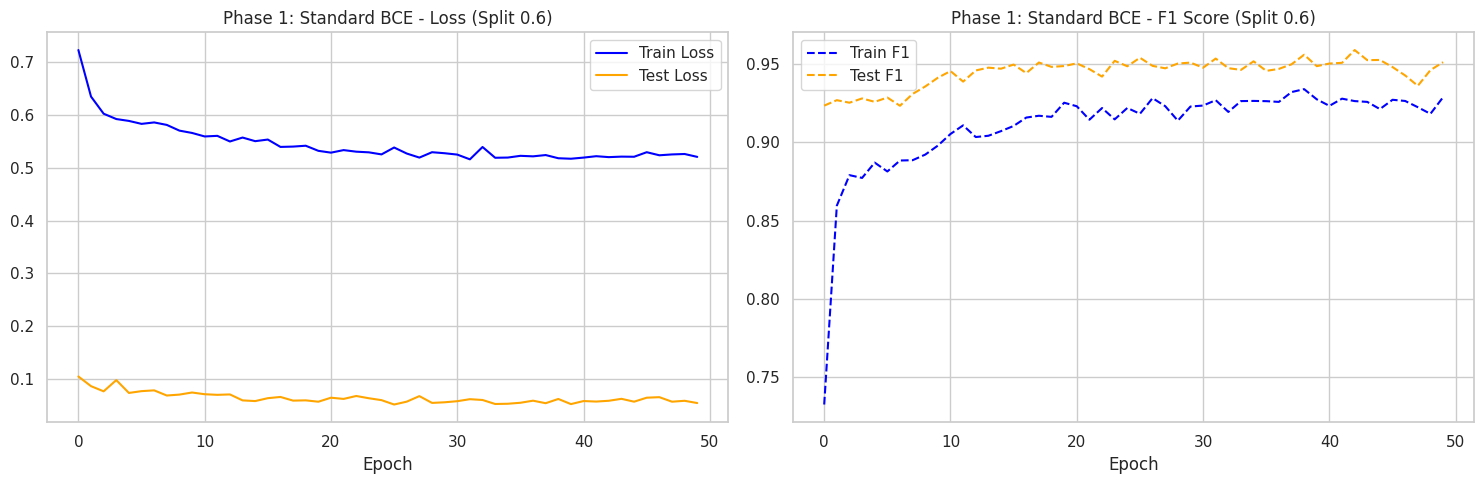

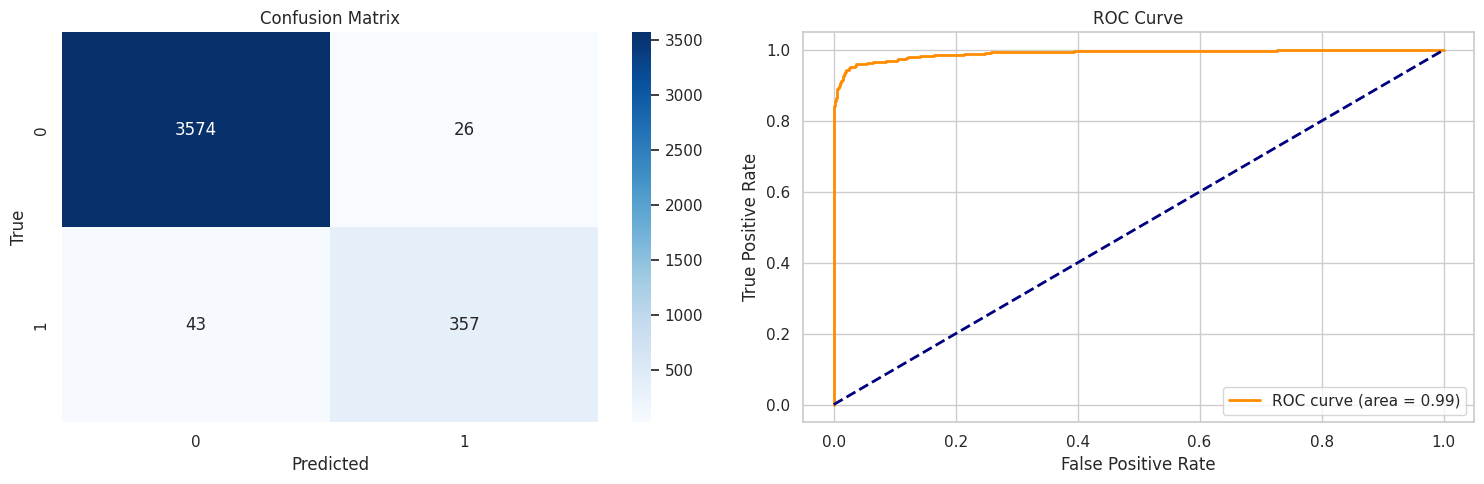


>>> STARTING Phase 2: Weighted BCE ...
Calculated pos_weight: 9.0000 (Pos: 600, Neg: 5400)

Ep  | Tr Loss | Tr F1   | Ts Loss | Ts Acc  | Ts Prec | Ts Rec  | Ts F1   | Thr  
---------------------------------------------------------------------------------------------------------
1   | 1.2897  | 0.7582  | 0.3293  | 0.9738  | 0.9496  | 0.8999  | 0.9229  | 0.706
2   | 1.0440  | 0.8466  | 0.2972  | 0.9742  | 0.9544  | 0.8979  | 0.9238  | 0.786
3   | 0.9801  | 0.8671  | 0.3190  | 0.9752  | 0.9500  | 0.9085  | 0.9279  | 0.773
4   | 0.9362  | 0.8718  | 0.2690  | 0.9740  | 0.9203  | 0.9389  | 0.9293  | 0.675
5   | 0.9286  | 0.8900  | 0.2730  | 0.9760  | 0.9309  | 0.9367  | 0.9338  | 0.819
6   | 0.9052  | 0.8924  | 0.2882  | 0.9772  | 0.9751  | 0.8962  | 0.9312  | 0.812
7   | 0.9107  | 0.8949  | 0.2978  | 0.9765  | 0.9364  | 0.9325  | 0.9344  | 0.730
8   | 0.8946  | 0.8934  | 0.2601  | 0.9805  | 0.9612  | 0.9281  | 0.9438  | 0.867
9   | 0.8410  | 0.8978  | 0.2557  | 0.9792  | 0.9580  | 0.9240 

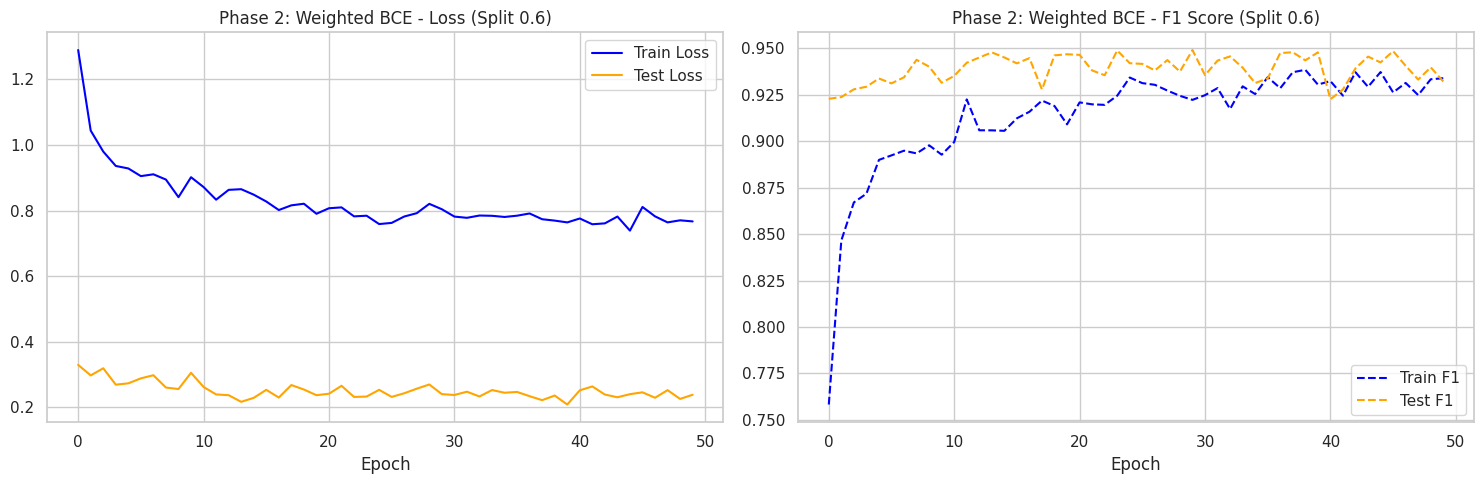

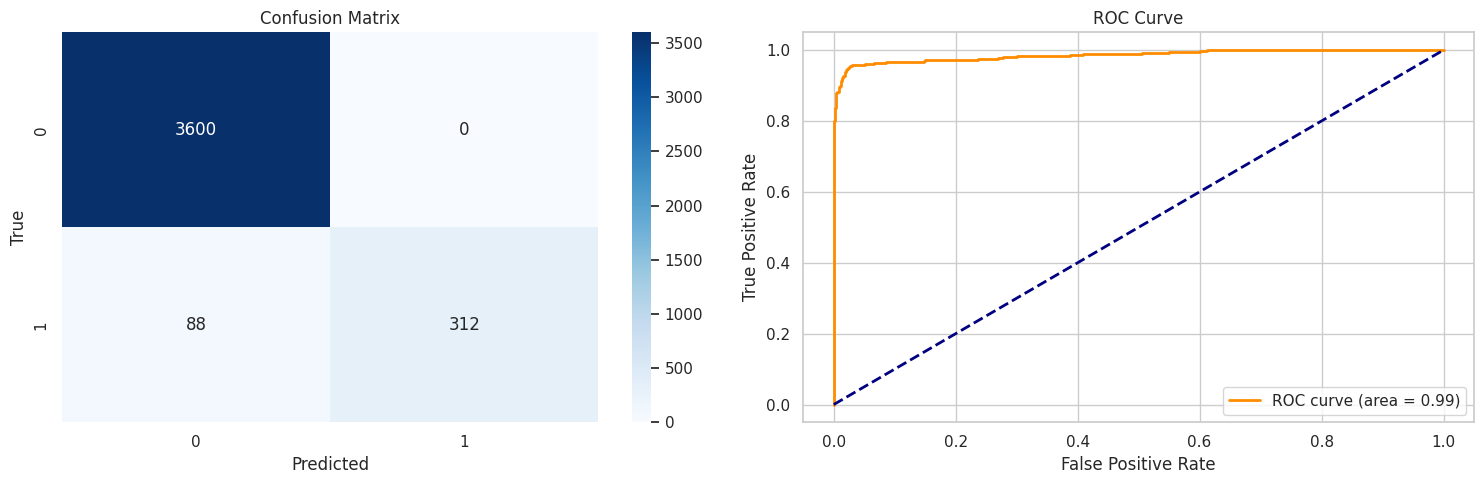


Saved epoch-wise results to 'epoch_wise_results.csv'


/kaggle/working/epoch_wise_results.csv


 FINAL SUMMARY OF ALL EXPERIMENTS 
Split                 Phase  Final_Test_Acc  Final_Test_Prec  Final_Test_Rec  Final_Test_F1  Final_Test_Loss  Optimal_Threshold
60/40 Phase 1: Standard BCE         0.98275         0.960113        0.942639       0.951158         0.055007           0.479771
60/40 Phase 2: Weighted BCE         0.97800         0.988069        0.890000       0.932165         0.238222           0.962445

Full results saved to 'experiment_summary_results.csv'


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool, GraphNorm
from torch_geometric.utils import dropout_edge
from torch_geometric.loader import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, 
    precision_recall_curve, confusion_matrix, roc_curve, auc
)

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
TRAIN_SPLITS_TO_TEST = [0.6] 
BATCH_SIZE = 64
LEARNING_RATE = 0.01
EPOCHS = 50               
SEED = 42
CONTRASTIVE_WEIGHT = 0.1  
CONTRASTIVE_TEMP = 0.5    

torch.manual_seed(SEED)
np.random.seed(SEED)

# Global list to store experiment results
all_experiment_results = []

# ✅ NEW: Epoch-wise logging storage
epoch_logs = []

# ==============================================================================
# 2. UTILITY FUNCTIONS
# ==============================================================================
def get_optimal_threshold(labels, logits):
    """Calculates the optimal prediction threshold by maximizing the F1 score on the PR curve."""
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    precisions, recalls, thresholds = precision_recall_curve(labels, probs)
    
    f1_scores = np.divide(
        2 * precisions * recalls, 
        precisions + recalls, 
        out=np.zeros_like(precisions), 
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_threshold

def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized Temperature-scaled Cross Entropy Loss for Graph Contrastive Learning."""
    device = z1.device
    batch_size = z1.size(0)
    
    z1 = F.normalize(z1, p=2, dim=1)
    z2 = F.normalize(z2, p=2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    
    sim_matrix = torch.mm(z, z.t()) / temperature
    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    sim_matrix = sim_matrix.masked_fill(mask, -9e15)
    
    targets = torch.cat([torch.arange(batch_size, 2*batch_size), 
                         torch.arange(0, batch_size)]).to(device)
    return F.cross_entropy(sim_matrix, targets)

# ==============================================================================
# 3. MODEL DEFINITION
# ==============================================================================
class AttentionGuidedEgoGAT(nn.Module):
    def __init__(self, num_node_features, hidden_channels, heads=4, num_classes=1, dropout=0.5, edge_dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.edge_dropout = edge_dropout
        self.hidden_channels = hidden_channels
        self.heads = heads
        self.ego_gate = nn.Linear(hidden_channels, hidden_channels * 2)

        self.res_proj1 = nn.Linear(num_node_features, hidden_channels * heads)
        self.res_proj2 = nn.Linear(hidden_channels * heads, hidden_channels)

        self.conv1 = GATv2Conv(num_node_features, hidden_channels, heads=heads, dropout=dropout)
        self.norm1 = GraphNorm(hidden_channels * heads)

        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout)
        self.norm2 = GraphNorm(hidden_channels)

        self.fc1 = nn.Linear(hidden_channels * 3, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)

    def forward(self, data, return_embeds=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.dropout(x, p=0.2, training=self.training)
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_dropout, training=self.training)

        res1 = self.res_proj1(x)
        x1 = self.conv1(x, edge_index)
        x1 = self.norm1(x1, batch)
        x = F.gelu(x1 + res1)
        x = F.dropout(x, p=self.dropout, training=self.training)

        res2 = self.res_proj2(x)
        x2 = self.conv2(x, edge_index)
        x2 = self.norm2(x2, batch)
        x = F.gelu(x2 + res2)
        x = F.dropout(x, p=self.dropout, training=self.training)

        if hasattr(data, 'root_node') and data.root_node is not None:
            ptr = data.ptr
            root_indices = ptr[:-1] + data.root_node
            x_root = x[root_indices]
        else:
            x_root = global_mean_pool(x, batch)

        x_max = global_max_pool(x, batch)
        x_mean = global_mean_pool(x, batch)
        x_neigh = torch.cat([x_mean, x_max], dim=1)

        gate = torch.sigmoid(self.ego_gate(x_root))
        x_neigh = gate * x_neigh
        x_final = torch.cat([x_root, x_neigh], dim=1)

        embeds = F.gelu(self.fc1(x_final))
        x_drop = F.dropout(embeds, p=0.5, training=self.training)
        logits = self.fc2(x_drop)

        if return_embeds:
            return logits, embeds
        return logits

# ==============================================================================
# 4. TRAINING & EVALUATION FUNCTIONS
# ==============================================================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_logits = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        target = batch.y.view(-1, 1).float()

        out1, embed1 = model(batch, return_embeds=True)
        out2, embed2 = model(batch, return_embeds=True)
        
        loss_bce = (criterion(out1, target) + criterion(out2, target)) / 2.0
        loss_con = nt_xent_loss(embed1, embed2, temperature=CONTRASTIVE_TEMP)
        loss = loss_bce + (CONTRASTIVE_WEIGHT * loss_con)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        all_logits.extend(out1.detach().cpu().numpy())
        all_labels.extend(target.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    opt_thresh = get_optimal_threshold(all_labels, all_logits)
    
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    preds = (probs >= opt_thresh).astype(int)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    
    return avg_loss, acc, f1, opt_thresh

def evaluate_epoch(model, loader, criterion, threshold, device):
    model.eval()
    all_logits = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            target = batch.y.view(-1, 1).float()
            out = model(batch)
            loss = criterion(out, target)
            total_loss += loss.item()
            all_logits.extend(out.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(loader)
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    preds = (probs >= threshold).astype(int)

    metrics = {
        'loss': avg_loss,
        'acc': accuracy_score(all_labels, preds),
        'prec': precision_score(all_labels, preds, average='macro', zero_division=0),
        'rec': recall_score(all_labels, preds, average='macro', zero_division=0),
        'f1': f1_score(all_labels, preds, average='macro', zero_division=0),
        'y_true': all_labels,
        'y_probs': probs,
        'y_preds': preds
    }
    return metrics

def plot_training_results(history, phase_name, split_val):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['test_loss'], label='Test Loss', color='orange')
    axes[0].set_title(f'{phase_name} - Loss (Split {split_val})')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train F1', color='blue', linestyle='--')
    axes[1].plot(history['test_f1'], label='Test F1', color='orange', linestyle='--')
    axes[1].set_title(f'{phase_name} - F1 Score (Split {split_val})')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

    last_eval = history['last_eval']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    cm = confusion_matrix(last_eval['y_true'], last_eval['y_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    fpr, tpr, _ = roc_curve(last_eval['y_true'], last_eval['y_probs'])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 5. MAIN EXPERIMENT RUNNER
# ==============================================================================
def run_experiment(train_split, ego_dataset):
    print(f"\n{'='*110}")
    print(f" EXPERIMENT: TRAIN/TEST SPLIT {train_split*100:.0f}% / {(1-train_split)*100:.0f}% ")
    print(f"{'='*110}")

    total_samples = len(ego_dataset)
    train_size = int(total_samples * train_split)
    train_dataset = ego_dataset[:train_size]
    test_dataset = ego_dataset[train_size:]

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    node_feats = ego_dataset.num_node_features if hasattr(ego_dataset, 'num_node_features') else 12

    phases = [
        {"name": "Phase 1: Standard BCE", "weighted": False, "tag": "std"},
        {"name": "Phase 2: Weighted BCE", "weighted": True, "tag": "weighted"}
    ]

    for phase in phases:
        print(f"\n>>> STARTING {phase['name']} ...")
        
        pos_weight = None
        if phase['weighted']:
            labels = [d.y.item() for d in train_dataset]
            pos_count = labels.count(1)
            neg_count = labels.count(0)
            weight_val = neg_count / pos_count if pos_count > 0 else 1.0
            pos_weight = torch.tensor([weight_val], dtype=torch.float).to(device)
            print(f"Calculated pos_weight: {weight_val:.4f} (Pos: {pos_count}, Neg: {neg_count})")

        model = AttentionGuidedEgoGAT(num_node_features=node_feats, hidden_channels=32).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        history = {'train_loss': [], 'test_loss': [], 'train_f1': [], 'test_f1': [], 'last_eval': None}

        print(f"\n{'Ep':<3} | {'Tr Loss':<7} | {'Tr F1':<7} | {'Ts Loss':<7} | {'Ts Acc':<7} | {'Ts Prec':<7} | {'Ts Rec':<7} | {'Ts F1':<7} | {'Thr':<5}")
        print("-" * 105)

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_acc, tr_f1, opt_thresh = train_epoch(model, train_loader, optimizer, criterion, device)
            ts_metrics = evaluate_epoch(model, test_loader, criterion, opt_thresh, device)

            history['train_loss'].append(tr_loss)
            history['test_loss'].append(ts_metrics['loss'])
            history['train_f1'].append(tr_f1)
            history['test_f1'].append(ts_metrics['f1'])
            history['last_eval'] = ts_metrics

            # ✅ NEW: Store epoch-wise metrics
            epoch_logs.append({
                'Split': f"{int(train_split*100)}/{int((1-train_split)*100)}",
                'Phase': phase['name'],
                'Epoch': epoch,
                'Train_Loss': tr_loss,
                'Train_F1': tr_f1,
                'Test_Loss': ts_metrics['loss'],
                'Test_Accuracy': ts_metrics['acc'],
                'Test_Precision': ts_metrics['prec'],
                'Test_Recall': ts_metrics['rec'],
                'Test_F1': ts_metrics['f1'],
                'Threshold': opt_thresh
            })

            print(f"{epoch:<3} | {tr_loss:.4f}  | {tr_f1:.4f}  | {ts_metrics['loss']:.4f}  | {ts_metrics['acc']:.4f}  | {ts_metrics['prec']:.4f}  | {ts_metrics['rec']:.4f}  | {ts_metrics['f1']:.4f}  | {opt_thresh:.3f}")

        # Final Results Recording
        all_experiment_results.append({
            'Split': f"{int(train_split*100)}/{int((1-train_split)*100)}",
            'Phase': phase['name'],
            'Final_Test_Acc': ts_metrics['acc'],
            'Final_Test_Prec': ts_metrics['prec'],
            'Final_Test_Rec': ts_metrics['rec'],
            'Final_Test_F1': ts_metrics['f1'],
            'Final_Test_Loss': ts_metrics['loss'],
            'Optimal_Threshold': opt_thresh
        })

        # Model Saving
        model_filename = f"model_split{int(train_split*100)}_{phase['tag']}.pt"
        torch.save({
            'model_state_dict': model.state_dict(),
            'split': train_split,
            'phase': phase['name'],
            'final_test_f1': ts_metrics['f1']
        }, model_filename)
        print(f"\nModel saved: {model_filename}")

        plot_training_results(history, phase['name'], train_split)

# ==============================================================================
# 6. EXECUTION
# ==============================================================================
if __name__ == "__main__":
    if 'ego_dataset' in locals() or 'ego_dataset' in globals():
        for split in TRAIN_SPLITS_TO_TEST:
            run_experiment(split, ego_dataset)
        
        # --- TABULAR DATA SUMMARY ---
        results_df = pd.DataFrame(all_experiment_results)
        results_df.to_csv("experiment_summary_results.csv", index=False)
        
        # ✅ NEW: Save epoch-wise CSV
        epoch_df = pd.DataFrame(epoch_logs)
        epoch_df.to_csv("epoch_wise_results.csv", index=False)

        print("\nSaved epoch-wise results to 'epoch_wise_results.csv'")

        from IPython.display import FileLink
        display(FileLink("epoch_wise_results.csv"))
        
        print("\n" + "="*50)
        print(" FINAL SUMMARY OF ALL EXPERIMENTS ")
        print("="*50)
        print(results_df.to_string(index=False))
        print("\nFull results saved to 'experiment_summary_results.csv'")
    else:
        print("Variable 'ego_dataset' not found. Please load your dataset first.")


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("epoch_wise_results.csv")

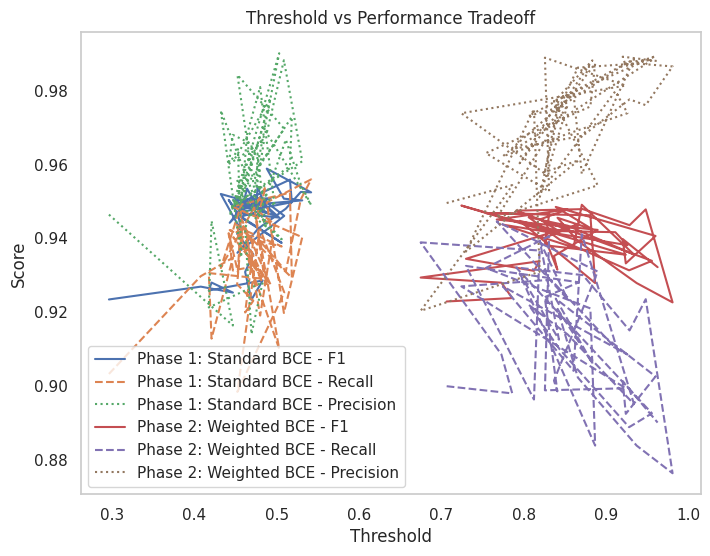

In [18]:
plt.figure(figsize=(8,6))

for phase in df['Phase'].unique():
    temp = df[df['Phase'] == phase]
    plt.plot(temp['Threshold'], temp['Test_F1'], label=f'{phase} - F1')
    plt.plot(temp['Threshold'], temp['Test_Recall'], linestyle='--', label=f'{phase} - Recall')
    plt.plot(temp['Threshold'], temp['Test_Precision'], linestyle=':', label=f'{phase} - Precision')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance Tradeoff")
plt.legend()
plt.grid()
plt.show()

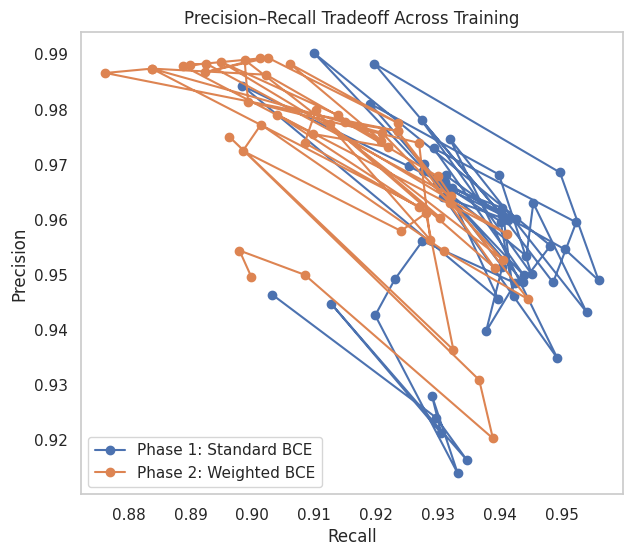

In [19]:
plt.figure(figsize=(7,6))

for phase in df['Phase'].unique():
    temp = df[df['Phase'] == phase]
    plt.plot(temp['Test_Recall'], temp['Test_Precision'], marker='o', label=phase)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Tradeoff Across Training")
plt.legend()
plt.grid()
plt.show()

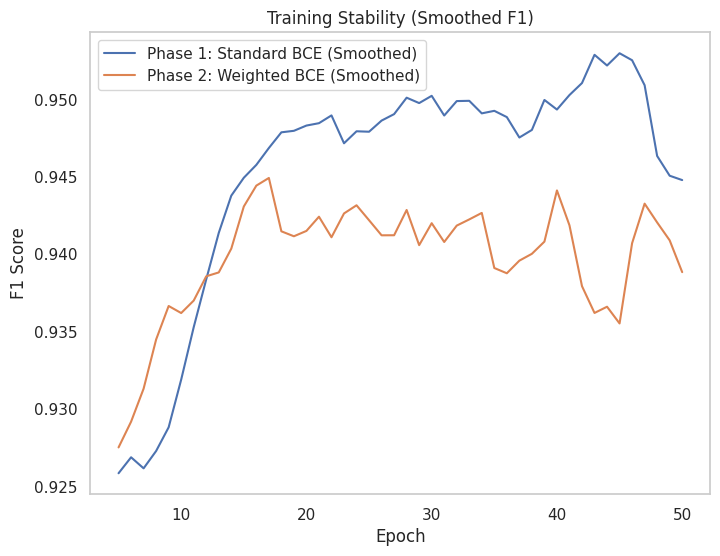

In [20]:
plt.figure(figsize=(8,6))

window = 5  # smoothing window

for phase in df['Phase'].unique():
    temp = df[df['Phase'] == phase]
    smoothed = temp['Test_F1'].rolling(window=window).mean()
    plt.plot(temp['Epoch'], smoothed, label=f'{phase} (Smoothed)')

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training Stability (Smoothed F1)")
plt.legend()
plt.grid()
plt.show()

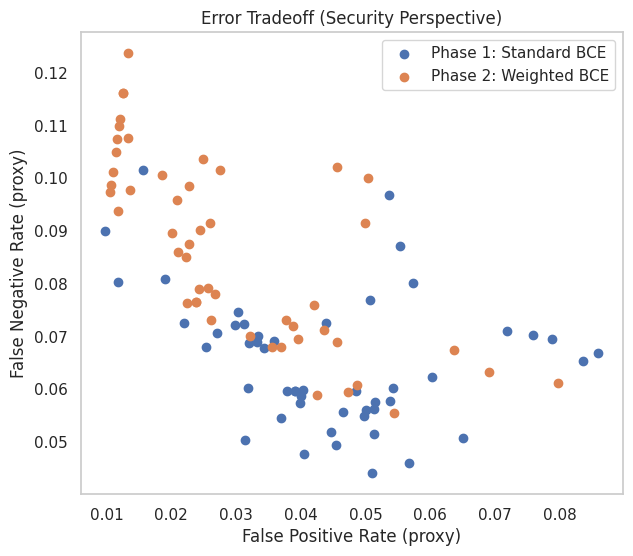

In [21]:
plt.figure(figsize=(7,6))

for phase in df['Phase'].unique():
    temp = df[df['Phase'] == phase]
    fp = 1 - temp['Test_Precision']
    fn = 1 - temp['Test_Recall']
    plt.scatter(fp, fn, label=phase)

plt.xlabel("False Positive Rate (proxy)")
plt.ylabel("False Negative Rate (proxy)")
plt.title("Error Tradeoff (Security Perspective)")
plt.legend()
plt.grid()
plt.show()

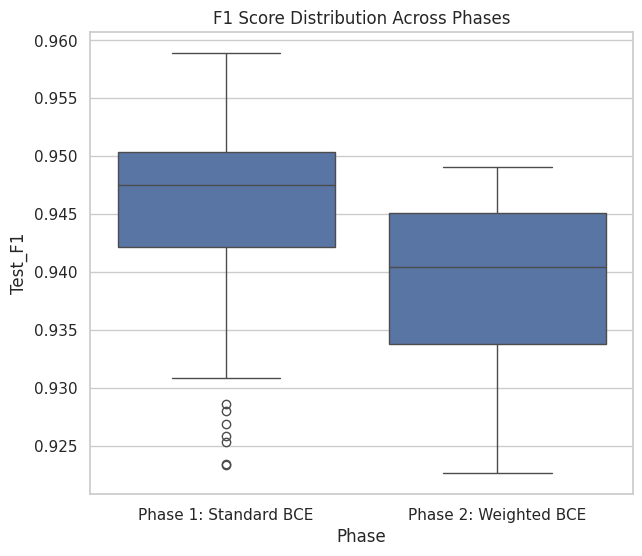

In [22]:
import seaborn as sns

plt.figure(figsize=(7,6))
sns.boxplot(data=df, x='Phase', y='Test_F1')

plt.title("F1 Score Distribution Across Phases")
plt.show()

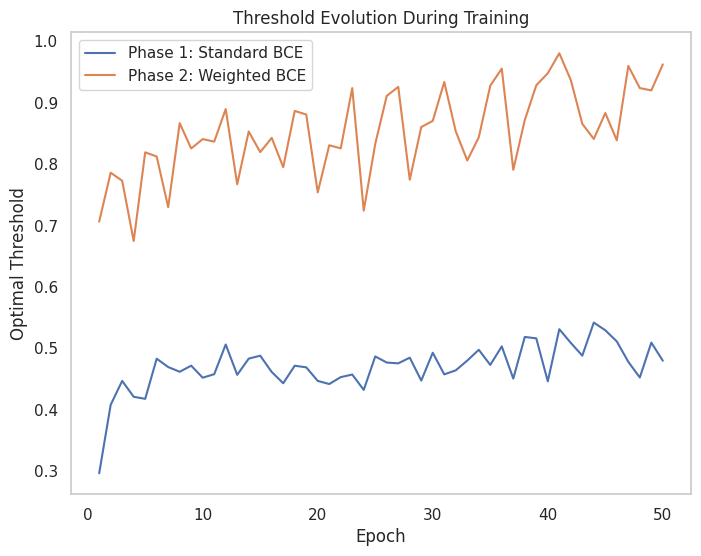

In [23]:
plt.figure(figsize=(8,6))

for phase in df['Phase'].unique():
    temp = df[df['Phase'] == phase]
    plt.plot(temp['Epoch'], temp['Threshold'], label=phase)

plt.xlabel("Epoch")
plt.ylabel("Optimal Threshold")
plt.title("Threshold Evolution During Training")
plt.legend()
plt.grid()
plt.show()

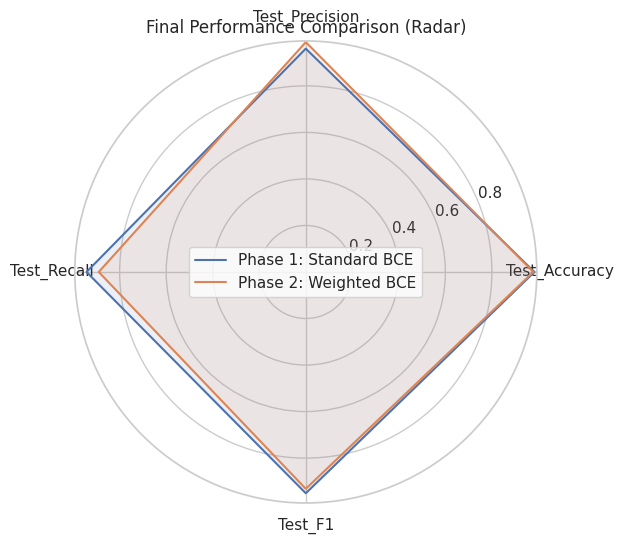

In [24]:
import numpy as np

phases = df['Phase'].unique()

metrics = ['Test_Accuracy','Test_Precision','Test_Recall','Test_F1']

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for phase in phases:
    temp = df[df['Phase']==phase].iloc[-1]
    values = [temp[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, label=phase)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.title("Final Performance Comparison (Radar)")
plt.legend()
plt.show()

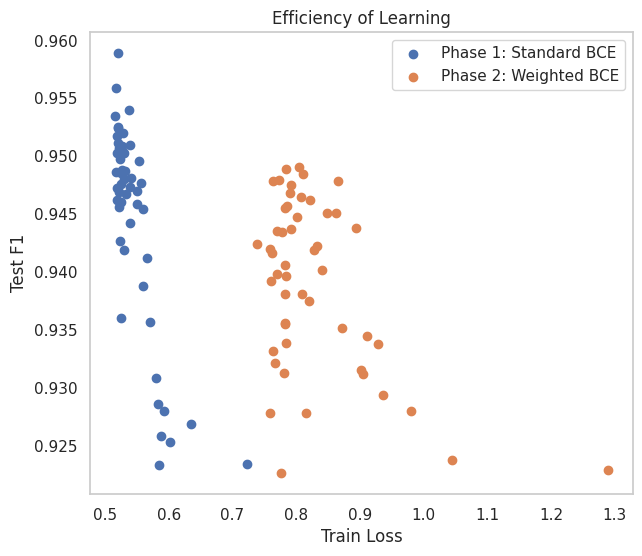

In [25]:
plt.figure(figsize=(7,6))

for phase in df['Phase'].unique():
    temp = df[df['Phase']==phase]
    plt.scatter(temp['Train_Loss'], temp['Test_F1'], label=phase)

plt.xlabel("Train Loss")
plt.ylabel("Test F1")
plt.title("Efficiency of Learning")
plt.legend()
plt.grid()
plt.show()